Лабораторная работа №2 (Определение бета-ритмов)

Касьяненко Вера и Кремпольская Екатерина

P3420


Импорт необходимых библиотек:

In [1]:
import os
from typing import Dict, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, welch, hilbert, iirnotch, detrend

try:
    from IPython.display import display
except Exception:
    display = print

Загрузка наших изменений.



1. Закрытые глаза, рок музыка
2. Закрытые глаза, решение в уме квадратного уравнения
3. Глаза открыты, умножение матриц на листочке
4. Глаза открыты, написание программы на загрузку и обработку csv файла
5. Глаза открыты, игра в шахматы
6. Глаза открыты, игра в CS2



In [ ]:
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1BZidwsxPPVho5L3X6vWdu7Fp0OCsKWCw' -O v2_1_A0_fixed.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1y1jtzYNrJVME2QNMNwAm6PJ7AfQxRnqL' -O v2_2_A0_fixed.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1TQdGfFKtaNnn1leiscTFW9IpbAhulTzc' -O v2_3_A0_fixed.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1UlmMIMmS3mm4MXx9nyxi_8fnONS3fVCt' -O v2_4_A0_fixed.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1DQ8F2lQc_F5WrC0bQtBNRi-VRDmWxyUc' -O v2_5_A0_fixed.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1da0gc-wU1y8HaG7Q5gPECwbKdsk4sKIq' -O v2_6_A0_fixed.csv

In [ ]:
CONDITIONS: Dict[str, str] = {
    "Закрытые глаза + рок": "v2_1_A0_fixed.csv",
    "Закрытые глаза + квадратное уравнение": "v2_2_A0_fixed.csv",
    "Открытые глаза + вышмат": "v2_3_A0_fixed.csv",
    "Открытые глаза + программирование": "v2_4_A0_fixed.csv",
    "Открытые глаза + шахматы": "v2_5_A0_fixed.csv",
    "Открытые глаза + CS2": "v2_6_A0_fixed.csv",
}

## Загрузка CSV и оценка fs

- убираем NaN, сортируем по времени, убираем дубли времени;
- делаем время от нуля


In [ ]:
# Чтение CSV и оценка fs
def read_eeg_csv(path: str) -> Tuple[np.ndarray, np.ndarray, float]:
    df = pd.read_csv(path)

    cand_t = ["time", "Time", "t", "timestamp"]
    cand_x = ["amplitude", "signal", "value", "eeg"]

    t_col = next((c for c in cand_t if c in df.columns), None)
    x_col = next((c for c in cand_x if c in df.columns), None)

    if t_col is None or x_col is None:
        t = df.iloc[:, 0].astype(float).to_numpy()
        x = df.iloc[:, 1].astype(float).to_numpy()
    else:
        t = df[t_col].astype(float).to_numpy()
        x = df[x_col].astype(float).to_numpy()

    # Убираем NaN/inf
    m = np.isfinite(t) & np.isfinite(x)
    t, x = t[m], x[m]

    # Сортировка по времени
    order = np.argsort(t)
    t, x = t[order], x[order]

    # Убираем дубли времени
    _, idx = np.unique(t, return_index=True)
    t, x = t[idx], x[idx]

    # Время от 0
    t = t - t[0]

    # Частота дискретизации
    dt = np.diff(t)
    dt = dt[dt > 0]

    fs = float(1.0 / np.median(dt))
    return t, x, fs


## Фильтры и очистка

Делаем предобработку:
- убираем постоянное смещение,
- оставляем полосу 1-40 Гц,
- если можно, вырезаем 50 Гц


In [ ]:
# Вспомогательные функции фильтрации
def bandpass(x: np.ndarray, fs: float, lo: float, hi: float, order: int = 4) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    nyq = 0.5 * fs

    hi = min(hi, nyq * 0.99)

    b, a = butter(order, [lo / nyq, hi / nyq], btype="band")
    return filtfilt(b, a, x)

def notch_50(x: np.ndarray, fs: float, notch_hz: float = 50.0, q: float = 30.0) -> np.ndarray:
    nyq = 0.5 * fs
    if notch_hz >= nyq * 0.99:
        return x
    w0 = notch_hz / nyq
    b, a = iirnotch(w0, q)
    return filtfilt(b, a, x)

def preprocess_wide(x: np.ndarray, fs: float, lo: float = 1.0, hi: float = 40.0, order: int = 4) -> np.ndarray:
    # убираем смещение
    y = detrend(np.asarray(x, dtype=float), type="constant")
    # оставляем 1-40 Гц
    y = bandpass(y, fs, lo, hi, order=order)
    # вырезаем 50 Гц (если возможно)
    y = notch_50(y, fs, notch_hz=50.0, q=30.0)
    return y

def beta_component_and_envelope(x: np.ndarray, fs: float, order: int = 4) -> Tuple[np.ndarray, np.ndarray]:
    # Бета 13-30 Гц
    xb = bandpass(x, fs, 13.0, 30.0, order=order)
    env = np.abs(hilbert(xb))
    return xb, env


## Метрики беты (через PSD)

Считаем по спектру (Welch):
- мощность в 1-40 Гц,
- мощность беты 13-30 Гц,
- долю беты,
- низкую и высокую бету отдельно


In [ ]:
# PSD и расчет мощностей
def bandpower(f: np.ndarray, pxx: np.ndarray, lo: float, hi: float) -> float:
    m = (f >= lo) & (f <= hi)
    if not np.any(m):
        return 0.0
    return float(np.trapezoid(pxx[m], f[m]))

def beta_metrics(x_raw: np.ndarray, fs: float) -> Dict[str, Any]:
    # Чистим сигнал в широкой полосе 1-40
    x_wide = preprocess_wide(x_raw, fs, lo=1.0, hi=40.0, order=4)

    # Welch PSD
    nperseg = int(min(2048, len(x_wide)))

    f, pxx = welch(x_wide, fs=fs, nperseg=nperseg)

    p_total = bandpower(f, pxx, 1.0, 40.0)
    p_beta  = bandpower(f, pxx, 13.0, 30.0)
    p_low   = bandpower(f, pxx, 13.0, 20.0)
    p_high  = bandpower(f, pxx, 20.0, 30.0)

    rel = (p_beta / p_total) if p_total > 0 else 0.0
    ratio = (p_high / p_low) if p_low > 0 else np.inf

    m = (f >= 13.0) & (f <= 30.0)
    peak_hz = float(f[m][np.argmax(pxx[m])]) if np.any(m) else np.nan

    return {
        "freqs": f,
        "psd": pxx,
        "beta_power": float(p_beta),
        "relative_power": float(rel),
        "low_beta_power": float(p_low),
        "high_beta_power": float(p_high),
        "high_low_ratio": float(ratio),
        "beta_peak_hz": float(peak_hz),
    }


## Прогон по всем условиям

In [ ]:
# Анализ всех условий
def analyze_conditions(conds: Dict[str, str]) -> Dict[str, Dict[str, Any]]:
    out: Dict[str, Dict[str, Any]] = {}

    for name, fp in conds.items():
        t, x_raw, fs = read_eeg_csv(fp)

        x_filtered = preprocess_wide(x_raw, fs, lo=1.0, hi=40.0, order=4)

        # Метрики по PSD
        met = beta_metrics(x_raw, fs)

        # Бета-составляющая и огибающая
        xb_sig, xb_env = beta_component_and_envelope(x_raw, fs, order=4)

        out[name] = {
            "t": t,
            "fs": fs,
            "signal_raw": x_raw,
            "signal_filtered": x_filtered,
            "beta_signal": xb_sig,
            "envelope": xb_env,
            "metrics": met,
        }

        print(f"{name}: relbeta={met['relative_power']:.4f} | beta={met['beta_power']:.6g}")

    return out

results_beta = analyze_conditions(CONDITIONS)

Закрытые глаза + рок: relbeta=0.3029 | beta=0.441099
Закрытые глаза + квадратное уравнение: relbeta=0.3036 | beta=0.457372
Открытые глаза + вышмат: relbeta=0.3044 | beta=0.640907
Открытые глаза + программирование: relbeta=0.2971 | beta=0.529014
Открытые глаза + шахматы: relbeta=0.3066 | beta=0.628369
Открытые глаза + CS2: relbeta=0.3042 | beta=0.473758


## Графики для каждого условия

1) исходный и отфильтрованный сигнал,  
2) PSD (Welch) и выделенная зона 13-30 Гц,  
3) бета-составляющая,  
4) огибающая беты



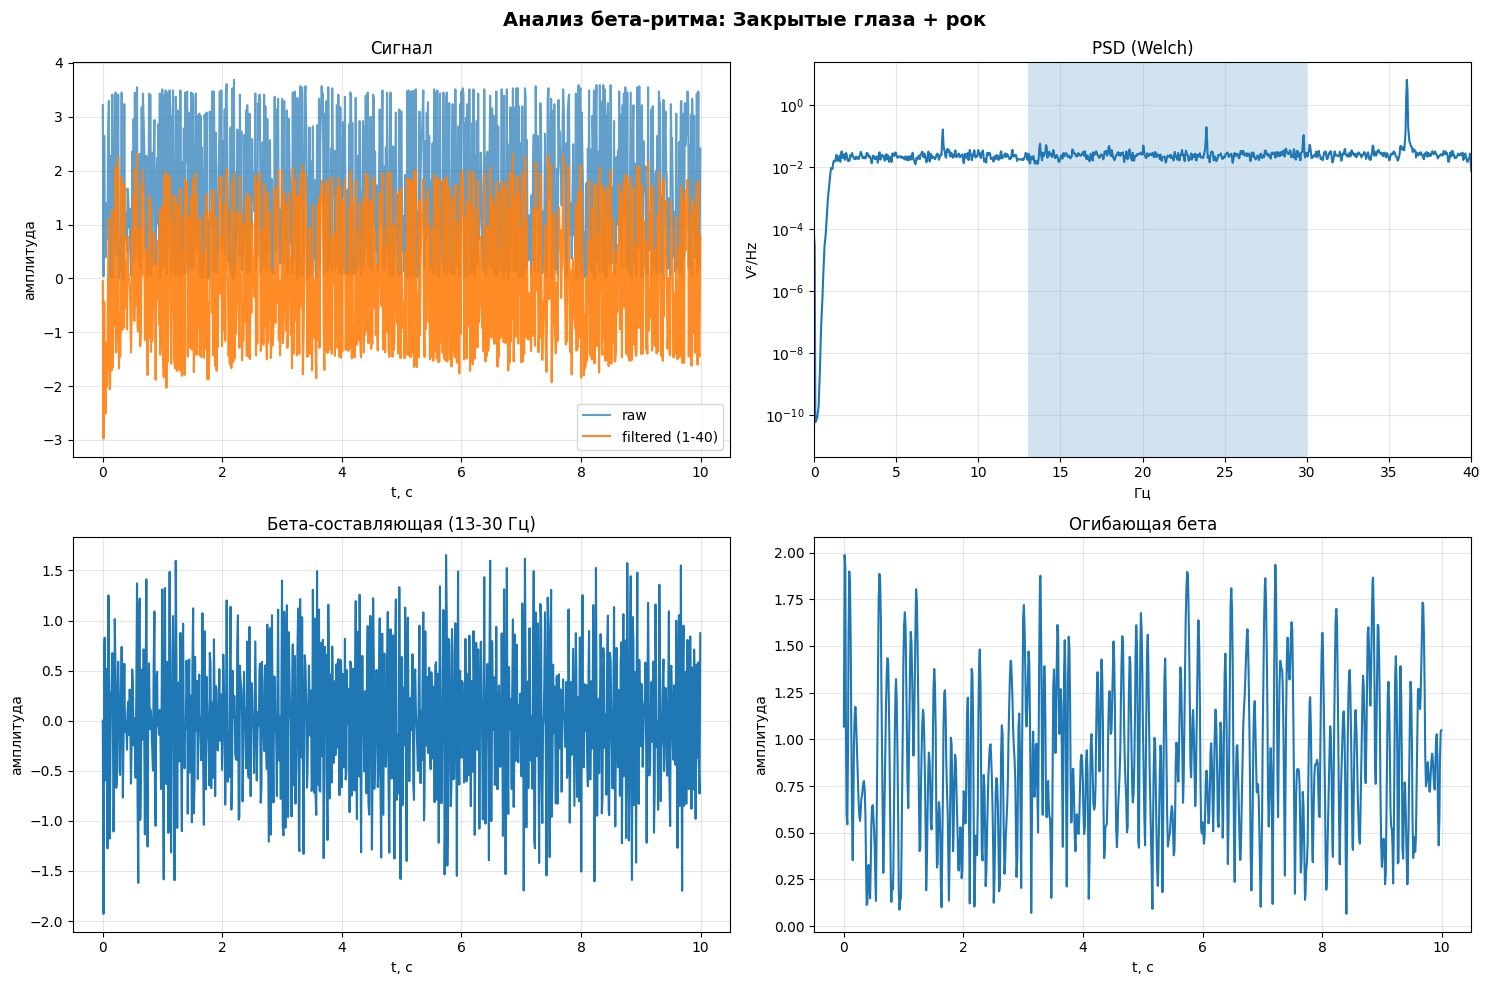

beta=0.441099, relbeta=0.3029, lowbeta=0.175387, highbeta=0.264646, ratio=1.509, peak=23.88 Hz



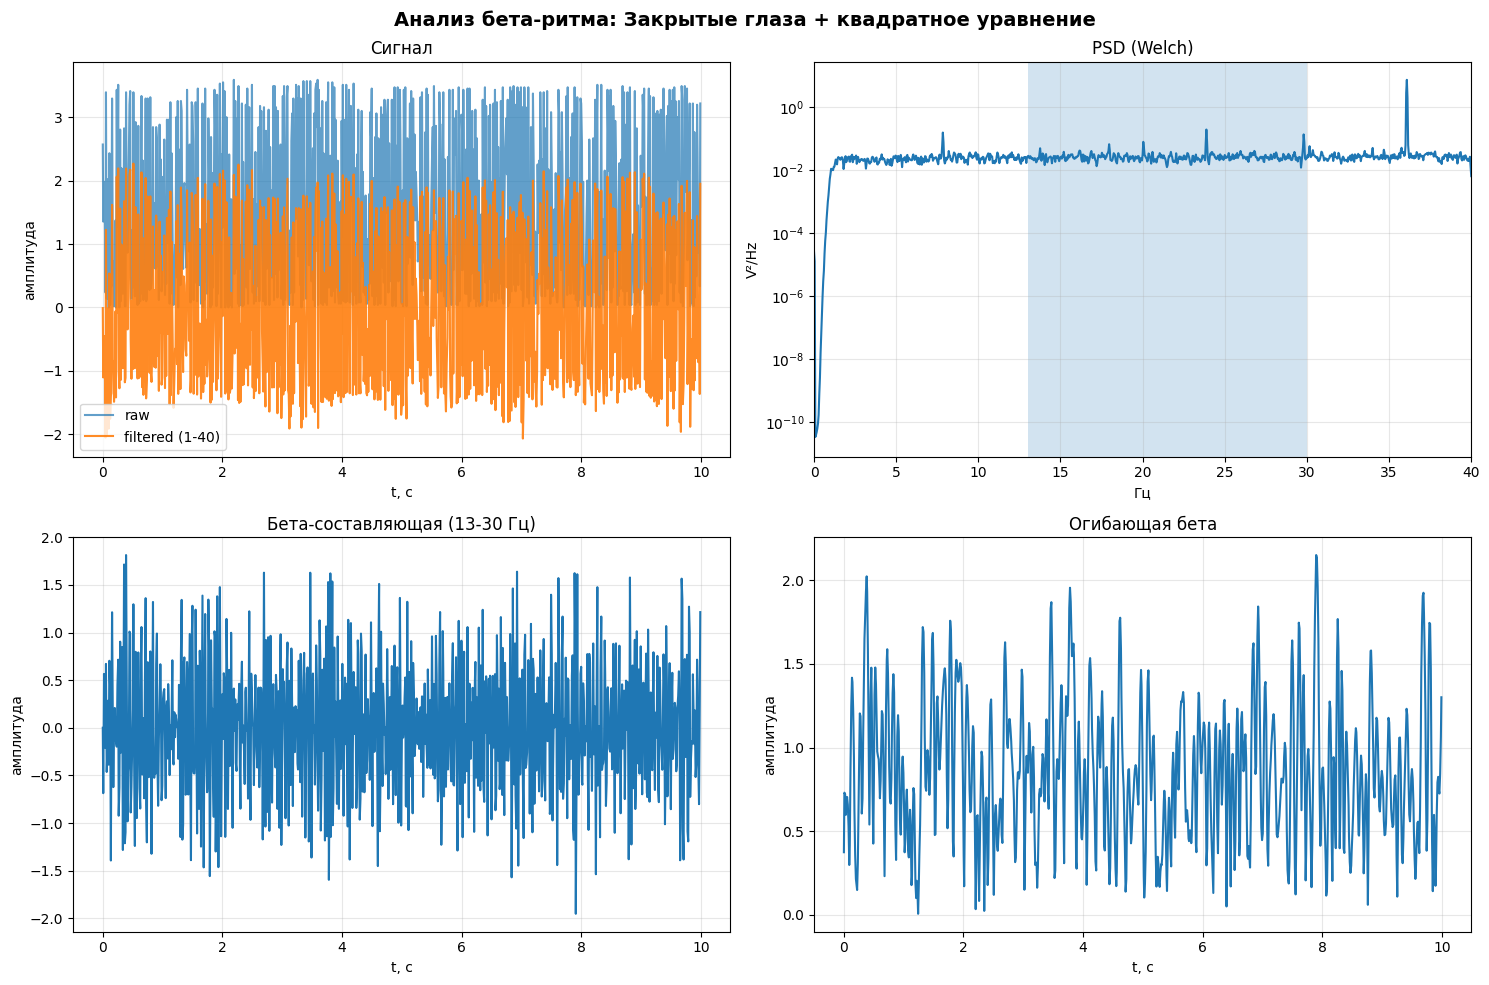

beta=0.457372, relbeta=0.3036, lowbeta=0.180787, highbeta=0.27555, ratio=1.524, peak=23.88 Hz



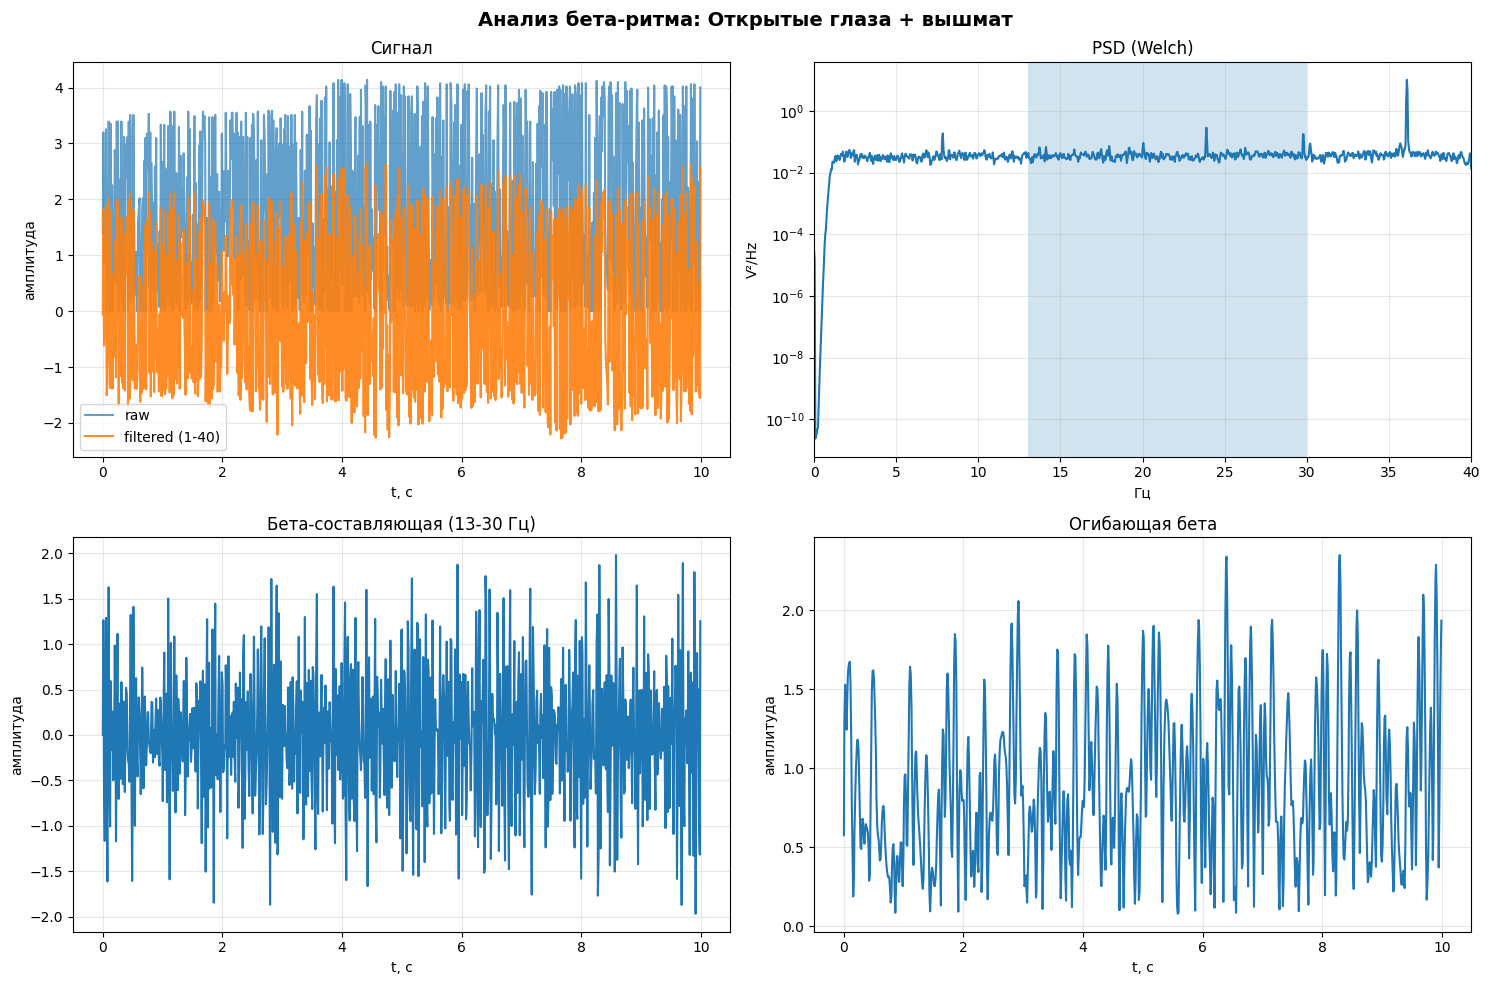

beta=0.640907, relbeta=0.3044, lowbeta=0.248825, highbeta=0.390303, ratio=1.569, peak=23.88 Hz



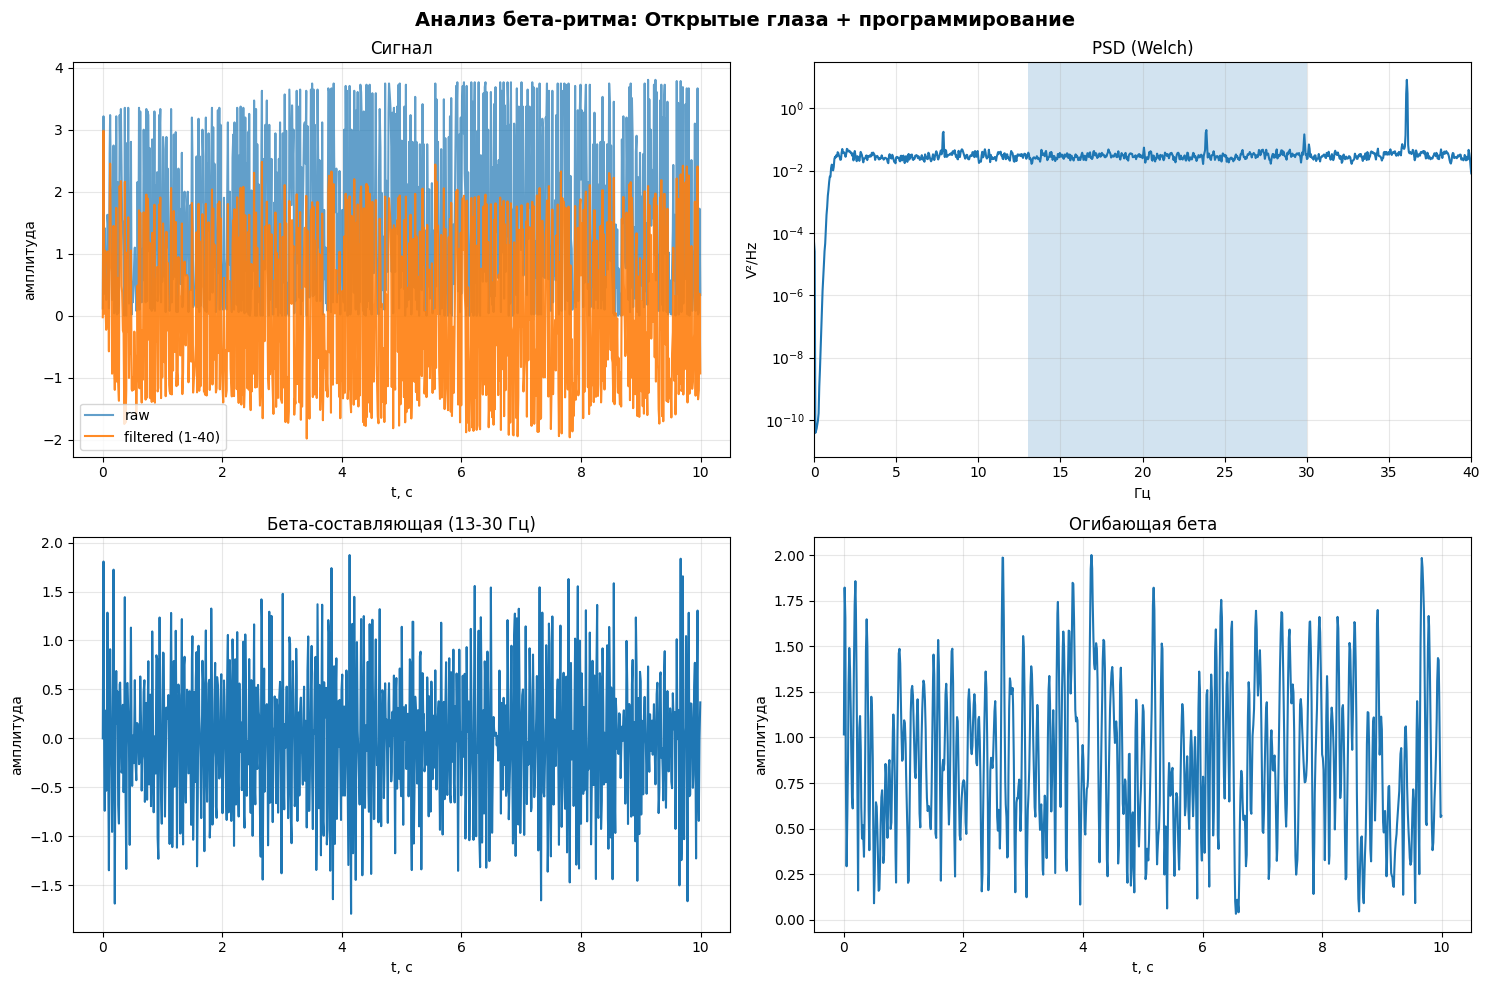

beta=0.529014, relbeta=0.2971, lowbeta=0.206365, highbeta=0.321558, ratio=1.558, peak=23.88 Hz



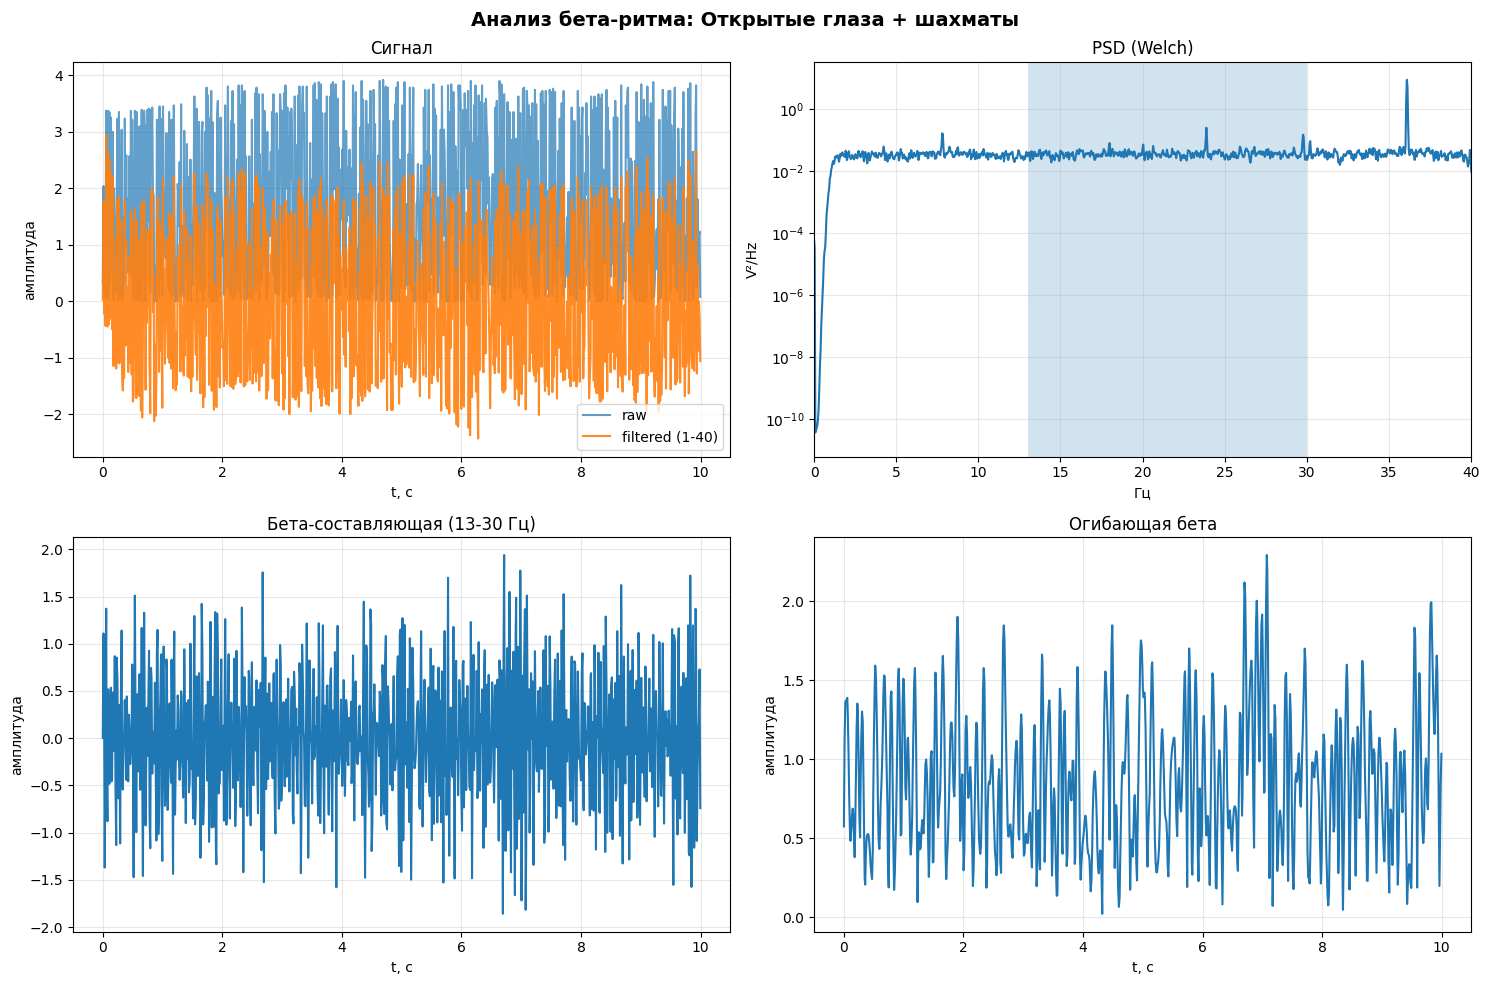

beta=0.628369, relbeta=0.3066, lowbeta=0.247567, highbeta=0.378982, ratio=1.531, peak=23.88 Hz



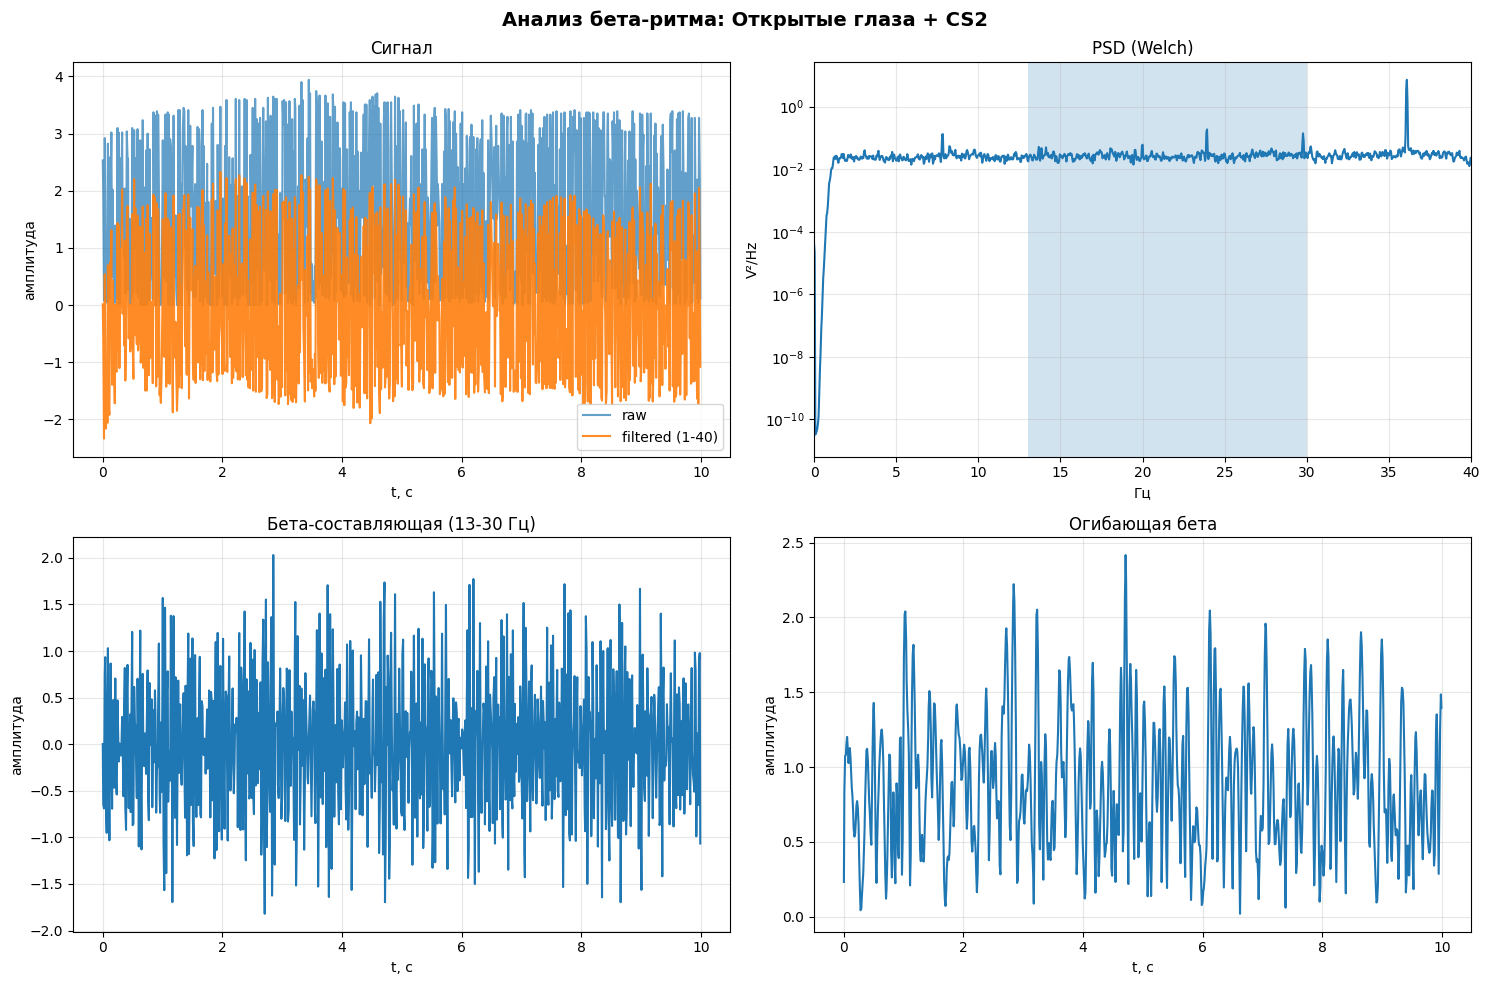

beta=0.473758, relbeta=0.3042, lowbeta=0.187516, highbeta=0.283904, ratio=1.514, peak=23.92 Hz


In [ ]:
# Индивидуальные графики
def plot_one_condition(name: str, d: Dict[str, Any], seconds: int = 10) -> None:
    t = d["t"]
    m = t <= seconds

    fig, ax = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"Анализ бета-ритма: {name}", fontsize=14, fontweight="bold")

    # raw vs filtered
    ax[0, 0].plot(t[m], d["signal_raw"][m], label="raw", alpha=0.7)
    ax[0, 0].plot(t[m], d["signal_filtered"][m], label="filtered (1-40)", alpha=0.9)
    ax[0, 0].set_title("Сигнал")
    ax[0, 0].set_xlabel("t, c")
    ax[0, 0].set_ylabel("амплитуда")
    ax[0, 0].grid(True, alpha=0.3)
    ax[0, 0].legend()

    # PSD
    ax[0, 1].semilogy(d["freqs"], d["psd"])
    ax[0, 1].axvspan(13, 30, alpha=0.2)
    ax[0, 1].set_xlim(0, 40)
    ax[0, 1].set_title("PSD (Welch)")
    ax[0, 1].set_xlabel("Гц")
    ax[0, 1].set_ylabel("V²/Hz")
    ax[0, 1].grid(True, alpha=0.3)

    # beta component
    ax[1, 0].plot(t[m], d["beta_signal"][m])
    ax[1, 0].set_title("Бета-составляющая (13-30 Гц)")
    ax[1, 0].set_xlabel("t, c")
    ax[1, 0].set_ylabel("амплитуда")
    ax[1, 0].grid(True, alpha=0.3)

    # envelope
    ax[1, 1].plot(t[m], d["envelope"][m])
    ax[1, 1].set_title("Огибающая бета")
    ax[1, 1].set_xlabel("t, c")
    ax[1, 1].set_ylabel("амплитуда")
    ax[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(
        f"beta={d['beta_power']:.6g}, relbeta={d['relative_power']:.4f}, "
        f"lowbeta={d['low_beta_power']:.6g}, highbeta={d['high_beta_power']:.6g}, "
        f"ratio={d['high_low_ratio']:.3f}, peak={d['beta_peak_hz']:.2f} Hz"
    )

def plot_all_individual(res: Dict[str, Dict[str, Any]], seconds: int = 10) -> None:
    for name, d in res.items():
        print("\n" + "=" * 70)
        plot_one_condition(name, d, seconds=seconds)

if results_beta:
    plot_all_individual(results_beta, seconds=10)

## Сравнение условий

Строим сравнение по:
- относительной бете,
- абсолютной бете,
- низкой/высокой бете


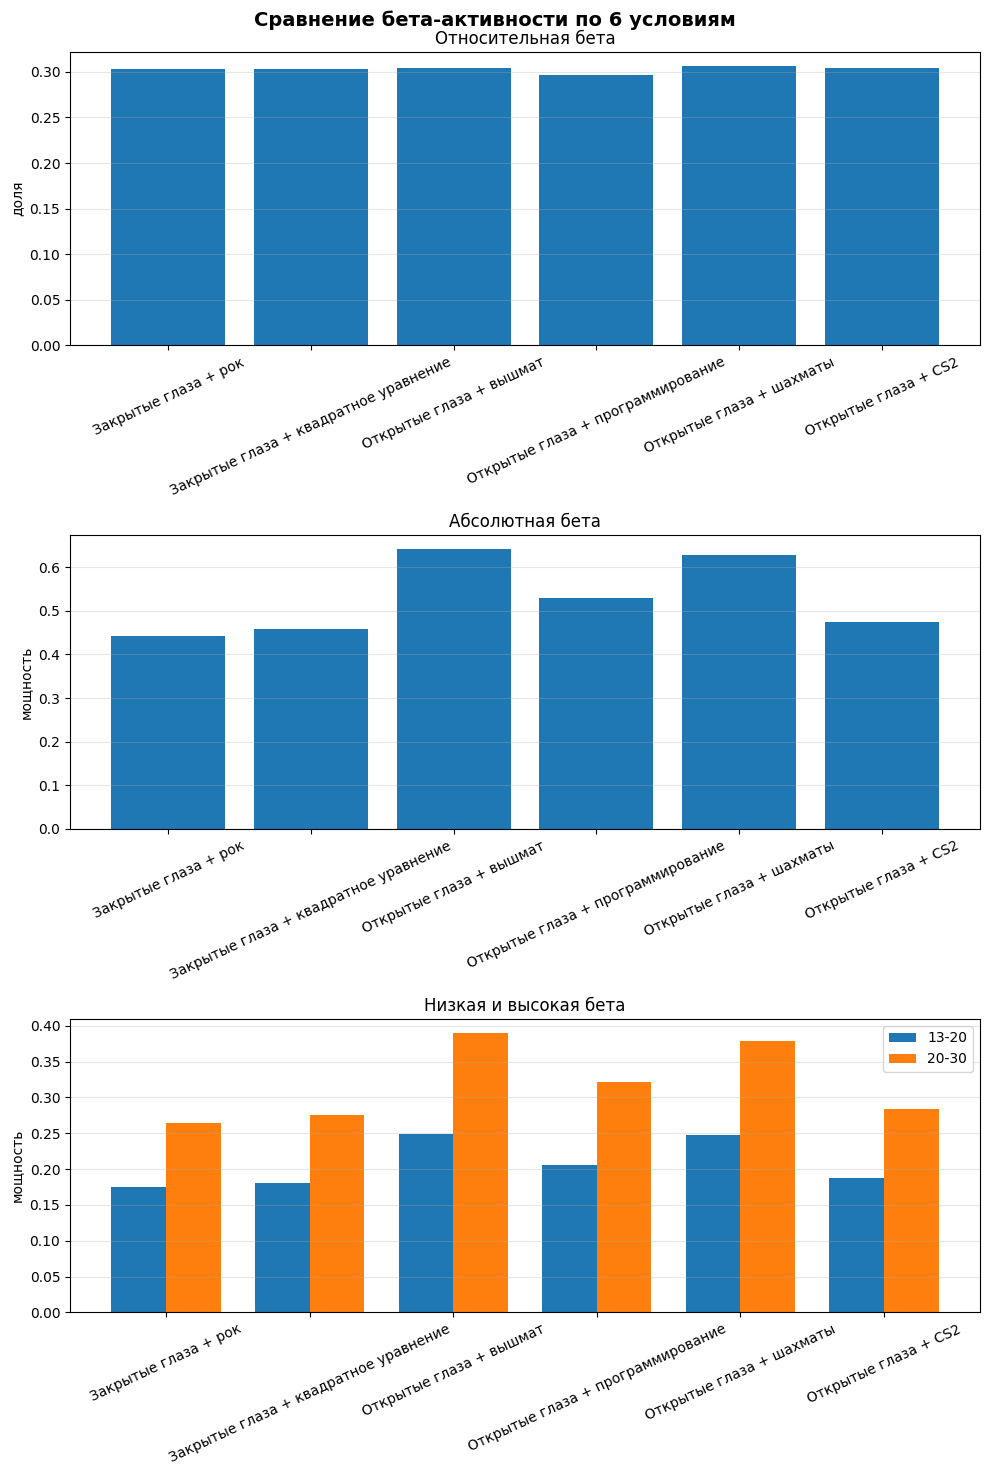

In [ ]:
# Сравнительные графики
def plot_comparison(res: Dict[str, Dict[str, Any]]) -> None:
    names = list(res.keys())

    rel = [res[n]["relative_power"] for n in names]
    total = [res[n]["beta_power"] for n in names]
    low = [res[n]["low_beta_power"] for n in names]
    high = [res[n]["high_beta_power"] for n in names]

    fig, ax = plt.subplots(3, 1, figsize=(10, 15))
    fig.suptitle("Сравнение бета-активности по 6 условиям", fontsize=14, fontweight="bold")

    # относительная мощность
    ax[0].bar(names, rel)
    ax[0].set_title("Относительная бета")
    ax[0].set_ylabel("доля")
    ax[0].tick_params(axis="x", rotation=25)
    ax[0].grid(True, axis="y", alpha=0.3)

    # абсолютная бета
    ax[1].bar(names, total)
    ax[1].set_title("Абсолютная бета")
    ax[1].set_ylabel("мощность")
    ax[1].tick_params(axis="x", rotation=25)
    ax[1].grid(True, axis="y", alpha=0.3)

    # low vs high beta
    x = np.arange(len(names))
    w = 0.38
    ax[2].bar(x - w/2, low, width=w, label="13-20")
    ax[2].bar(x + w/2, high, width=w, label="20-30")
    ax[2].set_title("Низкая и высокая бета")
    ax[2].set_xticks(x)
    ax[2].set_xticklabels(names, rotation=25)
    ax[2].set_ylabel("мощность")
    ax[2].legend()
    ax[2].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

if results_beta:
    plot_comparison(results_beta)


## Таблица результатов

In [ ]:
# Таблица и выводы
def build_report(res: Dict[str, Dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for name, d in res.items():
        rows.append({
            "Состояние": name,
            "Общая бета-мощность": d["beta_power"],
            "Отн. мощность": d["relative_power"],
            "Низкие бета (13-20)": d["low_beta_power"],
            "Высокие бета (20-30)": d["high_beta_power"],
        })

    df = (
        pd.DataFrame(rows)
        .sort_values("Общая бета-мощность", ascending=False)
        .reset_index(drop=True)
    )
    return df

def print_conclusions(df: pd.DataFrame) -> None:
    best = df.iloc[0]["Состояние"]
    worst = df.iloc[-1]["Состояние"]
    print(f"Наибольшая бета-активность: '{best}'")
    print(f"Наименьшая бета-активность: '{worst}'")

if results_beta:
    df_report = build_report(results_beta)
    display(df_report.style.format({
        "Общая бета-мощность": "{:.6g}",
        "Отн. мощность": "{:.4f}",
        "Низкие бета (13-20)": "{:.6g}",
        "Высокие бета (20-30)": "{:.6g}",
    }).set_caption("Результаты анализа бета-ритма"))

    print_conclusions(df_report)

,Состояние,Общая бета-мощность,Отн. мощность,Низкие бета (13-20),Высокие бета (20-30)
0,Открытые глаза + вышмат,0.640907,0.3044,0.248825,0.390303
1,Открытые глаза + шахматы,0.628369,0.3066,0.247567,0.378982
2,Открытые глаза + программирование,0.529014,0.2971,0.206365,0.321558
3,Открытые глаза + CS2,0.473758,0.3042,0.187516,0.283904
4,Закрытые глаза + квадратное уравнение,0.457372,0.3036,0.180787,0.27555
5,Закрытые глаза + рок,0.441099,0.3029,0.175387,0.264646


Наибольшая бета-активность: 'Открытые глаза + вышмат'
Наименьшая бета-активность: 'Закрытые глаза + рок'


## Выводы

По общей бета-мощности условия выстроились так:

1. Открытые глаза + вышмат - 0.6409  
2. Открытые глаза + шахматы - 0.6284  
3. Открытые глаза + программирование - 0.5290  
4. Открытые глаза + CS2 - 0.4738  
5. Закрытые глаза + квадратное уравнение - 0.4574  
6. Закрытые глаза + рок - 0.4411  

То есть максимальная бета получилась при вышмате и шахматах, а минимальная - при закрытых глазах + рок.

Относительная мощность почти одинаковая во всех условиях: примерно 0.297-0.307, а вот общий уровень сигнала в бета-диапазоне меняется сильнее.

Открытые глаза + сложные задачи (вышмат, шахматы) дают больше беты, это ожидаемо: при концентрации и активной умственной работе бета обычно выраженнее Интересный момент: "закрытые глаза + квадратное уравнение" оказалось ниже, чем часть условий с открытыми глазами. В целом это нормально: открытые глаза сами по себе повышают вовлеченность.

Картина в целом логичная: чем больше концентрации и "работы головой", тем выше бета.
